In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


In [63]:

df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv') 

In [64]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [65]:
print(df.isnull().sum())


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [66]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [67]:
print(df.describe())

               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     1.000000     0.625350  
75% 

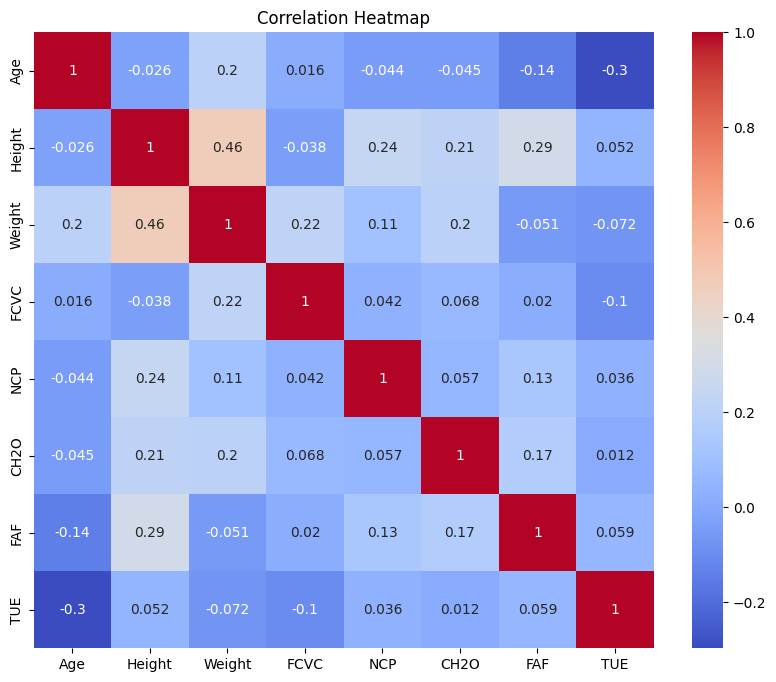

In [68]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

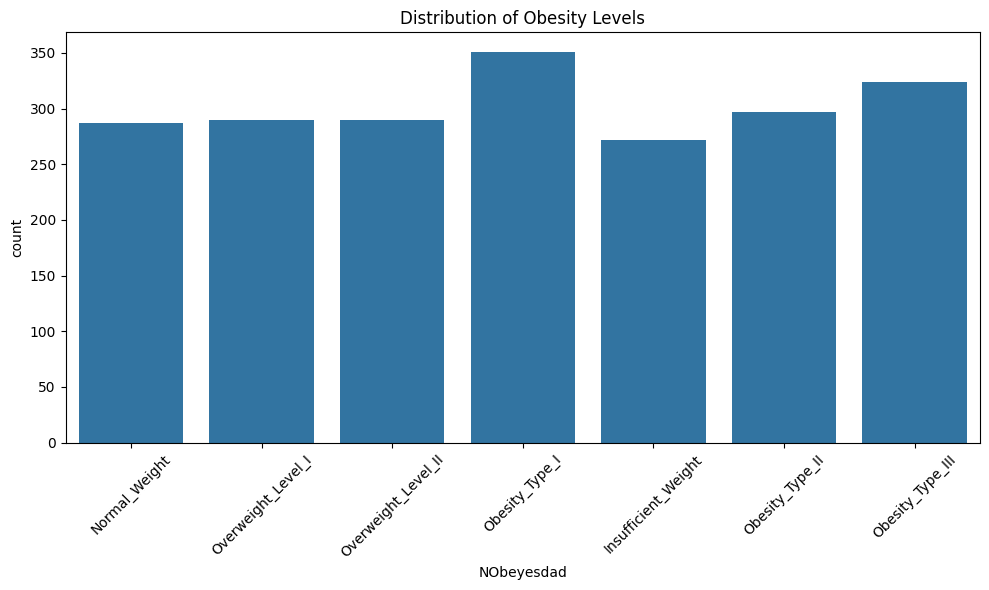

In [69]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NObeyesdad')
plt.title('Distribution of Obesity Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

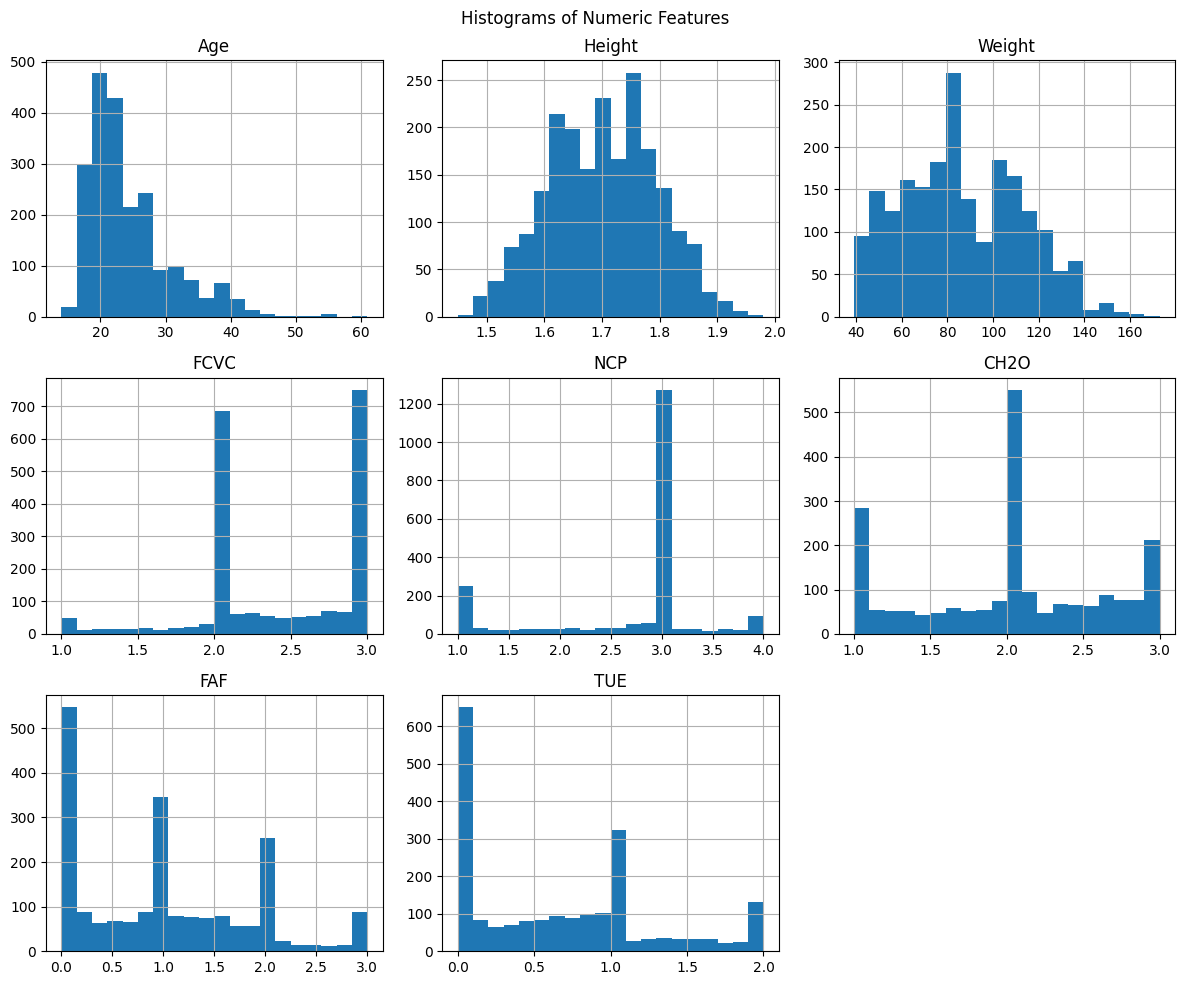

In [70]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].hist(bins=20, figsize=(12, 10))
plt.suptitle('Histograms of Numeric Features')
plt.tight_layout()
plt.show()

In [71]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

In [72]:
categorical_cols = X.select_dtypes(include=['object']).columns

In [73]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [74]:
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [108]:
k = 10 
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_scaled, y_encoded)

selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]
print("Selected features:", list(selected_feature_names))

Selected features: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC', 'CALC', 'MTRANS']


In [109]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y_encoded, test_size=0.2, random_state=42
# )

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
 model = DecisionTreeClassifier(
    criterion='entropy',

    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [112]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.9479905437352246

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.96        56
      Normal_Weight       0.90      0.90      0.90        62
     Obesity_Type_I       0.95      0.94      0.94        78
    Obesity_Type_II       0.96      0.95      0.96        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.94      0.91      0.93        56
Overweight_Level_II       0.94      0.96      0.95        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



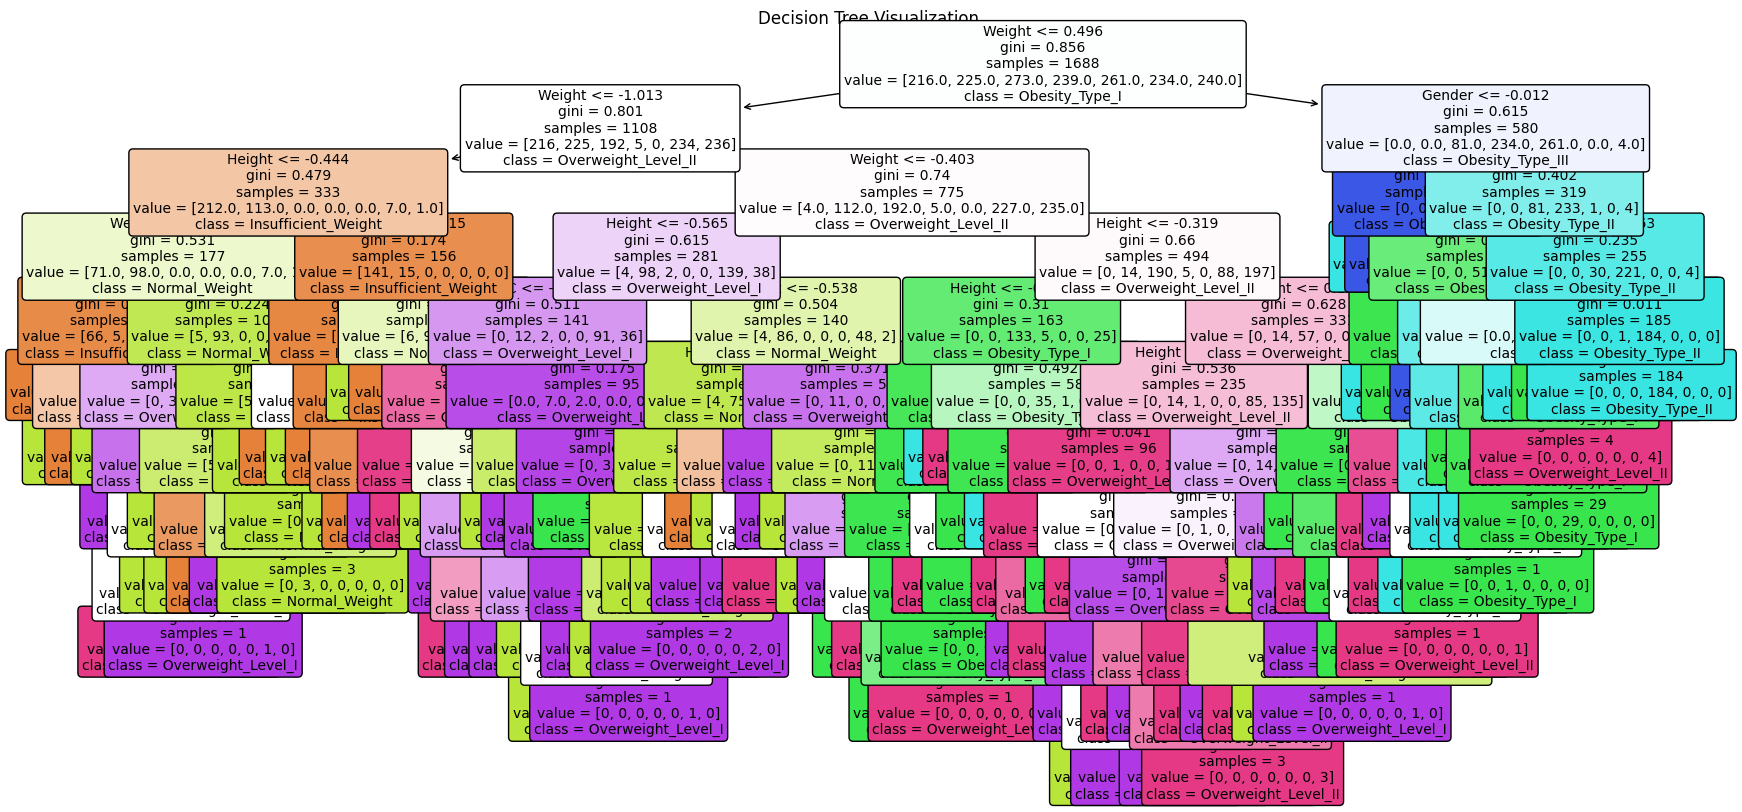

In [113]:

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    filled=True,
    feature_names=selected_feature_names,
    class_names=target_encoder.classes_,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
# model = DecisionTreeClassifier(
#     criterion='entropy',
#     max_depth=5,
#     min_samples_leaf=4,
#     random_state=42
# )
# model.fit(X_train, y_train)


C:\Users\hwi\AppData\Local\Temp\ipykernel_27472\2553353344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


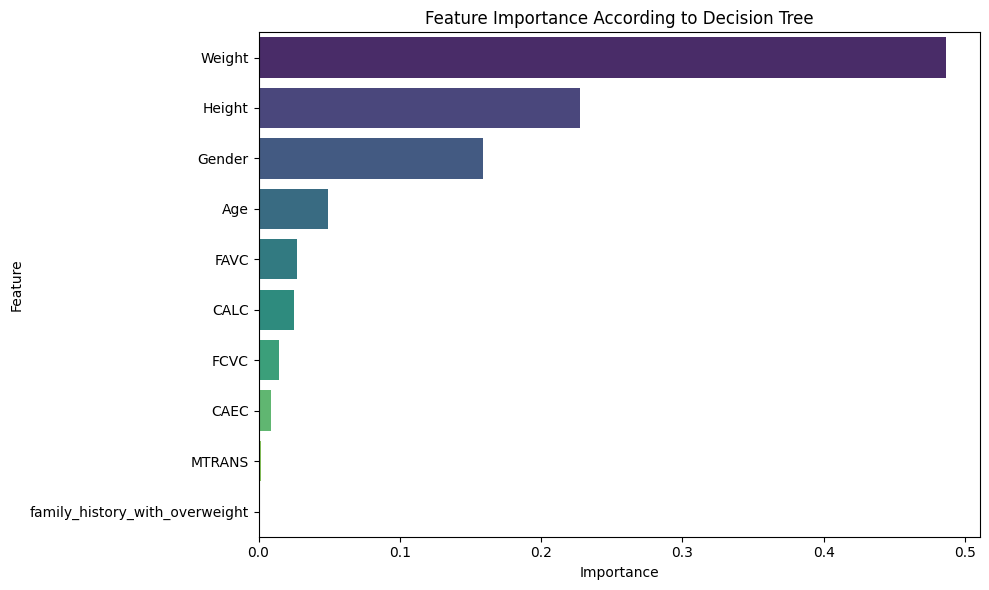

In [115]:
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance According to Decision Tree')
plt.tight_layout()
plt.show()


Train Accuracy: 1.0
Test Accuracy: 0.9479905437352246

=== Classification Report (Test Set) ===

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.96        56
      Normal_Weight       0.90      0.90      0.90        62
     Obesity_Type_I       0.95      0.94      0.94        78
    Obesity_Type_II       0.96      0.95      0.96        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.94      0.91      0.93        56
Overweight_Level_II       0.94      0.96      0.95        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



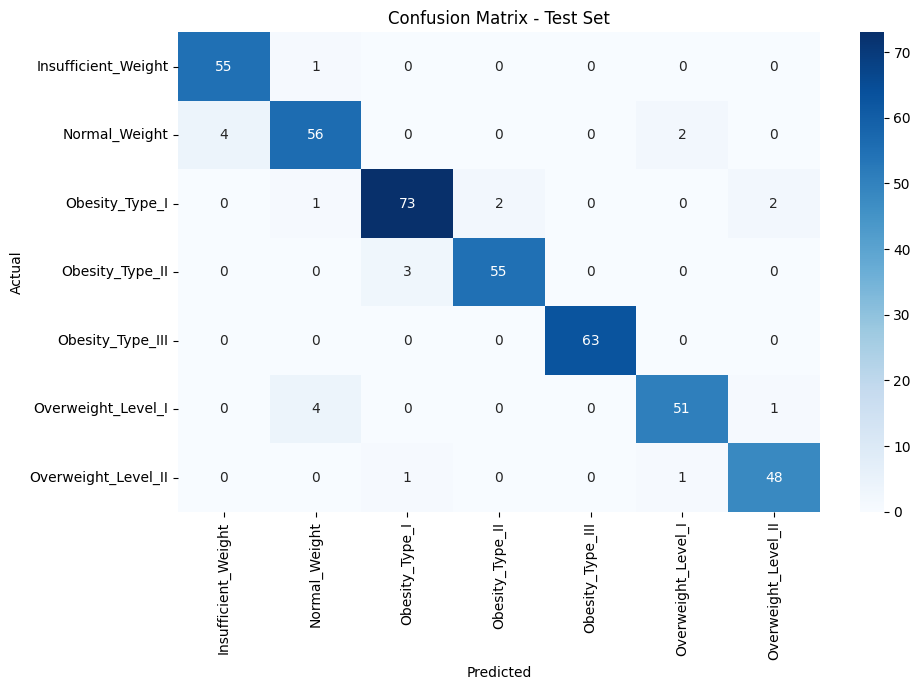

In [116]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\n=== Classification Report (Test Set) ===\n")
print(classification_report(y_test, y_test_pred, target_names=target_encoder.classes_))

conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters Found: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9520200867381877


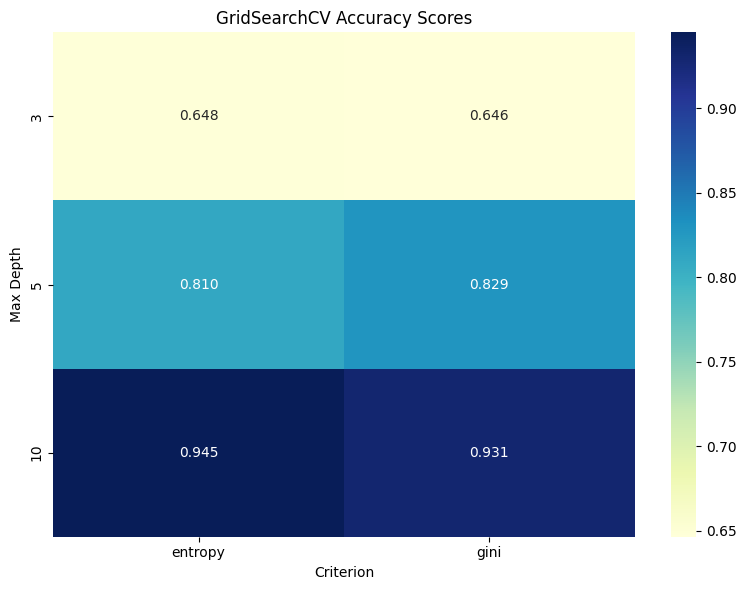

In [117]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

results_df = pd.DataFrame(grid_search.cv_results_)

pivot_table = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_criterion'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap='YlGnBu')
plt.title("GridSearchCV Accuracy Scores")
plt.xlabel("Criterion")
plt.ylabel("Max Depth")
plt.tight_layout()
plt.show()


In [118]:
default_model = DecisionTreeClassifier(random_state=42)
default_model.fit(X_train, y_train)
default_preds = default_model.predict(X_test)

print("=== Default Model ===")
print("Accuracy:", accuracy_score(y_test, default_preds))
print(classification_report(y_test, default_preds, target_names=target_encoder.classes_))


tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

print("\n=== Tuned Model ===")
print("Accuracy:", accuracy_score(y_test, tuned_preds))
print(classification_report(y_test, tuned_preds, target_names=target_encoder.classes_))

=== Default Model ===
Accuracy: 0.9479905437352246
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.96        56
      Normal_Weight       0.90      0.90      0.90        62
     Obesity_Type_I       0.95      0.94      0.94        78
    Obesity_Type_II       0.96      0.95      0.96        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.94      0.91      0.93        56
Overweight_Level_II       0.94      0.96      0.95        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423


=== Tuned Model ===
Accuracy: 0.9645390070921985
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.95      0.93        56
      Normal_Weight       0.93      0.90      0.92        62
     Obesity_Type_I       1.00      0.96 

In [ ]:


overfit_model = DecisionTreeClassifier(
    criterion='entropy',         
    max_depth=None,              
    min_samples_split=2,         
    min_samples_leaf=1,          
    splitter='random',           
    random_state=42
)

overfit_model.fit(X_train, y_train)


y_train_overfit = overfit_model.predict(X_train1)
y_test_overfit = overfit_model.predict(X_test)

print("=== Overfit Model ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_overfit))
print("Test Accuracy:", accuracy_score(y_test, y_test_overfit))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_overfit, target_names=target_encoder.classes_))


=== Overfit Model ===
Train Accuracy: 1.0
Test Accuracy: 0.7612293144208038

Classification Report (Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.81      0.82      0.81        56
      Normal_Weight       0.77      0.55      0.64        62
     Obesity_Type_I       0.83      0.71      0.76        78
    Obesity_Type_II       0.84      0.93      0.89        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.54      0.68      0.60        56
Overweight_Level_II       0.56      0.64      0.60        50

           accuracy                           0.76       423
          macro avg       0.76      0.76      0.76       423
       weighted avg       0.77      0.76      0.76       423



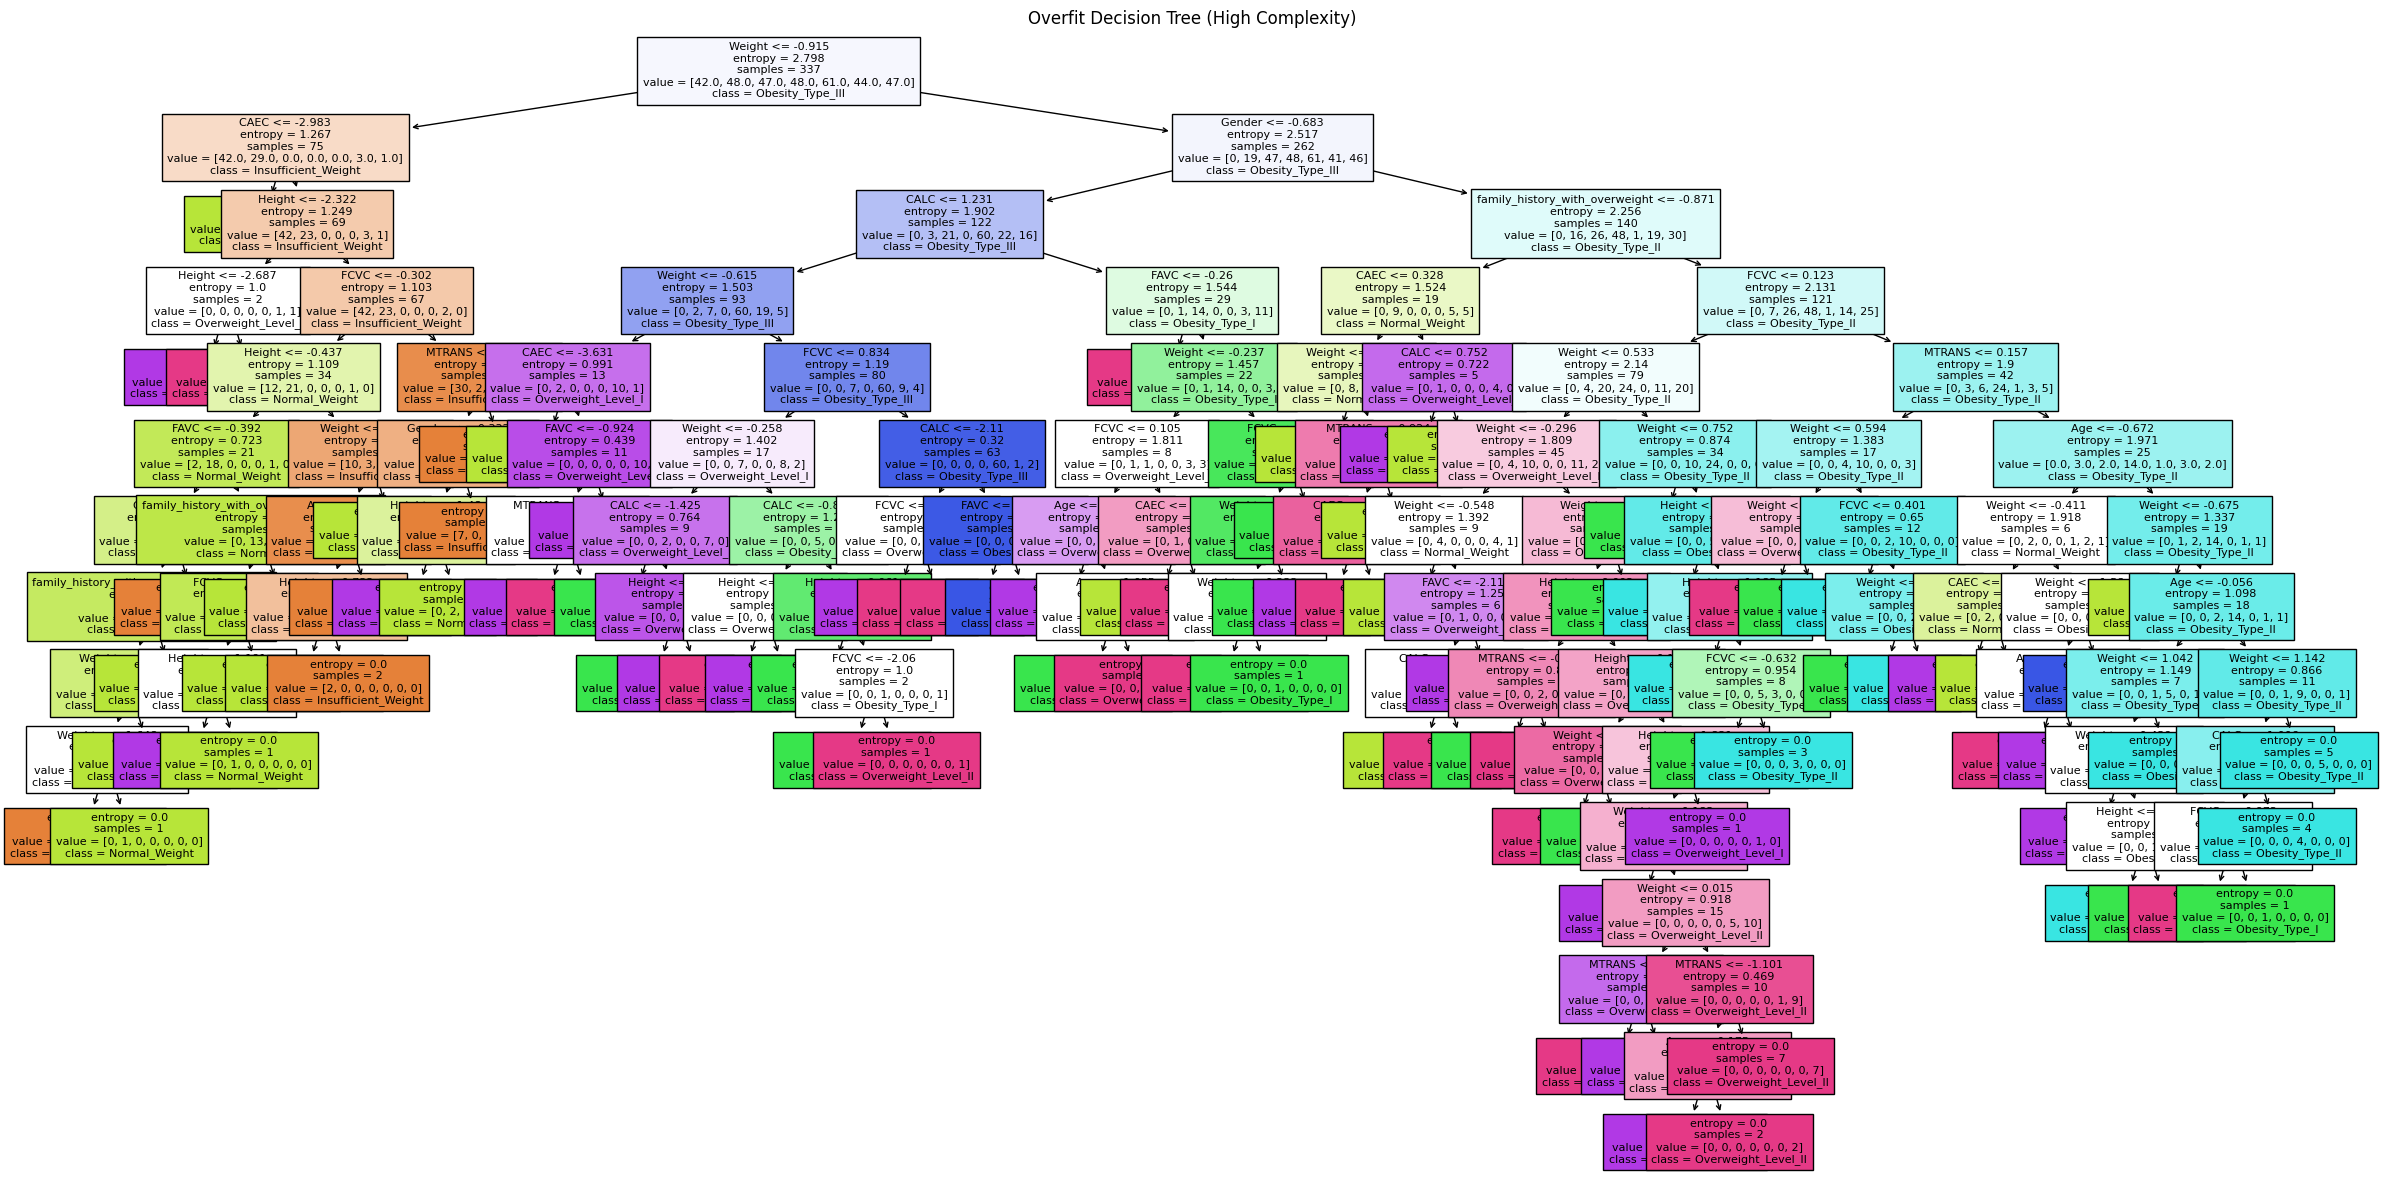

In [138]:

plt.figure(figsize=(24, 12))
plot_tree(
    overfit_model,
    filled=True,
    feature_names=selected_feature_names,
    class_names=target_encoder.classes_,
    fontsize=8
)
plt.title("Overfit Decision Tree (High Complexity)")
plt.tight_layout()
plt.show()
